# EX 6 — Comparative Analysis of VGG16, ResNet18 and GoogLeNet

**AI23531 Deep Learning Lab — Individual Experiment**

The code and the output below are preserved from the uploaded `Copy_of_deep_learning_lab.ipynb`.

Using device: cuda
GPU: Tesla T4


100%|██████████| 170M/170M [01:33<00:00, 1.82MB/s]


Training images: 50000
Testing images : 10000

Training: VGG16
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 75.4MB/s]


Trainable parameters: 134.3 Million
Epoch [1/1] Loss: 0.8529
Training Time: 93.42 seconds
Accuracy: 80.31 %

Training: ResNet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


...

100%|██████████| 49.7M/49.7M [00:00<00:00, 199MB/s]


Trainable parameters: 11.99 Million


/usr/local/lib/python3.13/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


Epoch [1/1] Loss: 2.7344
Training Time: 27.94 seconds
Accuracy: 84.58 %

             COMPARATIVE SUMMARY


,Model,Parameters (M),Train Time (s),Accuracy (%)
0,VGG16,134.30,93.42,80.31
1,ResNet18,11.18,21.17,88.33
2,GoogLeNet,11.99,27.94,84.58


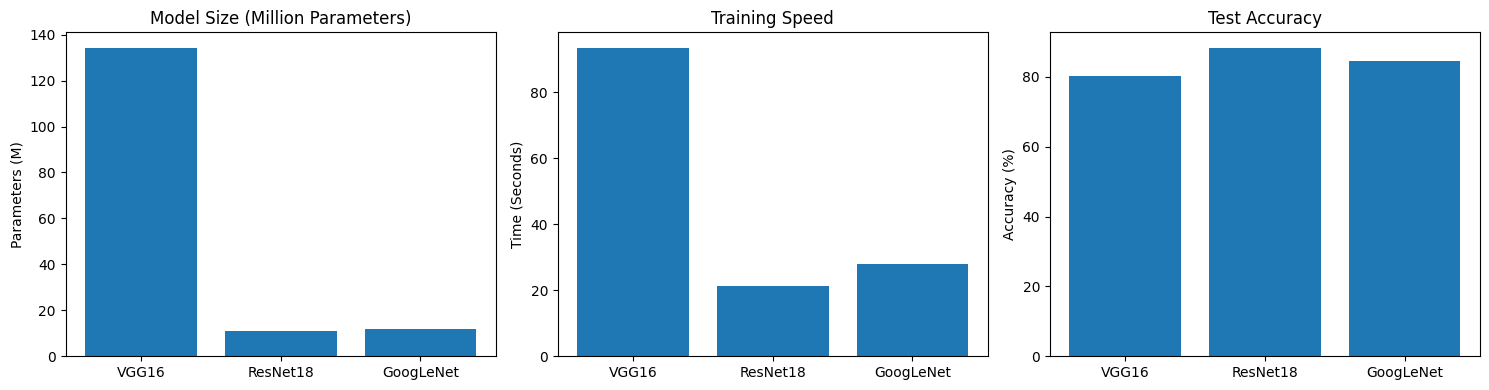

In [1]:
# ============================================================
# CIFAR-10: VGG16 vs ResNet18 vs GoogLeNet
# Google Colab Version
# ============================================================

import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 1. Device Configuration
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not enabled. Go to Runtime → Change runtime type → GPU")


# ------------------------------------------------------------
# 2. Data Preparation
# ------------------------------------------------------------

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])


# Download CIFAR-10
trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)


# Data loaders
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training images:", len(trainset))
print("Testing images :", len(testset))


# ------------------------------------------------------------
# 3. Create Models
# ------------------------------------------------------------

def get_model(name, num_classes=10):

    if name == "VGG16":

        model = models.vgg16(
            weights=models.VGG16_Weights.DEFAULT
        )

        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            num_classes
        )

    elif name == "ResNet18":

        model = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )

    elif name == "GoogLeNet":

        model = models.googlenet(
            weights=models.GoogLeNet_Weights.DEFAULT,
            aux_logits=True
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )

    else:
        raise ValueError("Unknown model name")

    return model.to(device)


# ------------------------------------------------------------
# 4. Count Trainable Parameters
# ------------------------------------------------------------

def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


# ------------------------------------------------------------
# 5. Train + Evaluate
# ------------------------------------------------------------

def train_and_eval(model_name, epochs=1):

    print("\n" + "=" * 50)
    print("Training:", model_name)
    print("=" * 50)

    model = get_model(model_name)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.0001
    )

    param_count = count_parameters(model)

    print(
        "Trainable parameters:",
        round(param_count / 1e6, 2),
        "Million"
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    start_time = time.time()

    model.train()

    for epoch in range(epochs):

        running_loss = 0.0

        for i, (inputs, labels) in enumerate(trainloader):

            # Limit batches for faster execution
            if i >= 100:
                break

            inputs = inputs.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            outputs = model(inputs)

            # GoogLeNet returns auxiliary outputs during training
            if isinstance(outputs, tuple):
                main_output, aux1, aux2 = outputs

                loss = (
                    criterion(main_output, labels)
                    + 0.3 * criterion(aux1, labels)
                    + 0.3 * criterion(aux2, labels)
                )
            else:
                loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {running_loss / min(100, len(trainloader)):.4f}"
        )

    training_time = time.time() - start_time

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for i, (inputs, labels) in enumerate(testloader):

            # Evaluate first 30 batches
            if i >= 30:
                break

            inputs = inputs.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(inputs)

            # During evaluation GoogLeNet returns only main output
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            _, predicted = torch.max(
                outputs.data,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = 100 * correct / total

    print("Training Time:", round(training_time, 2), "seconds")
    print("Accuracy:", round(accuracy, 2), "%")

    return param_count, training_time, accuracy


# ------------------------------------------------------------
# 6. Benchmark Models
# ------------------------------------------------------------

architectures = [
    "VGG16",
    "ResNet18",
    "GoogLeNet"
]

results = []

for arch in architectures:

    params, train_time, acc = train_and_eval(
        arch,
        epochs=1
    )

    results.append({
        "Model": arch,
        "Parameters (M)": round(params / 1e6, 2),
        "Train Time (s)": round(train_time, 2),
        "Accuracy (%)": round(acc, 2)
    })


# ------------------------------------------------------------
# 7. Summary Table
# ------------------------------------------------------------

df = pd.DataFrame(results)

print("\n" + "=" * 50)
print("             COMPARATIVE SUMMARY")
print("=" * 50)

display(df)


# ------------------------------------------------------------
# 8. Plot Results
# ------------------------------------------------------------

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

# Model Parameters
ax[0].bar(
    df["Model"],
    df["Parameters (M)"]
)

ax[0].set_title(
    "Model Size (Million Parameters)"
)

ax[0].set_ylabel(
    "Parameters (M)"
)


# Training Time
ax[1].bar(
    df["Model"],
    df["Train Time (s)"]
)

ax[1].set_title(
    "Training Speed"
)

ax[1].set_ylabel(
    "Time (Seconds)"
)


# Accuracy
ax[2].bar(
    df["Model"],
    df["Accuracy (%)"]
)

ax[2].set_title(
    "Test Accuracy"
)

ax[2].set_ylabel(
    "Accuracy (%)"
)


plt.tight_layout()
plt.show()